In [1]:
import os
import pandas as pd

def concat_csvs_from_folder(folder_path):
    all_dfs = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder_path, filename)
            try:
                df = pd.read_csv(file_path)
                all_dfs.append(df)
                print(f"✅ Loaded {filename} ({len(df)} rows)")
            except Exception as e:
                print(f"⚠️ Failed to read {filename}: {e}")

    if not all_dfs:
        raise ValueError("No valid CSVs found in folder")

    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n📊 Combined {len(all_dfs)} CSVs → {len(combined_df)} total rows")
    return combined_df

# Example usage
folder_path = "backtest_results"
big_df = concat_csvs_from_folder(folder_path)


✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-12.csv (271 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-06.csv (339 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-01-03.csv (299 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-01-02.csv (309 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-07.csv (322 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-13.csv (302 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-05.csv (277 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-11.csv (289 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-04-18.csv (200 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-10.csv (274 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-04-19.csv (200 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-04.csv (311 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-04-09.csv (211 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-03-14.csv (330 rows)
✅ Loaded sbs_nba_ensemble_model_1_results_2025-0

In [2]:
big_df

,player_name,player_id,bet_type,over_prob,under_prob,adj_over_prob,adj_under_prob,over_odds,under_odds,line,...,overKellyStake,underKellyStake,overEV,underEV,bankroll,gameId,dateStart,lineTime,calculatedAt,profit
0,Miles Bridges,941,player_assists,0.42,0.57,0.49,0.51,130,-166,4.5,...,98.35,0.00,12.57,-0.00,1000,15059,2025-03-12T23:40:00Z,2025-03-12T23:28:34Z,2025-10-09T12:49:52.951197,127.85
1,Caris LeVert,317,player_assists,0.42,0.65,0.49,0.52,120,-154,3.5,...,65.68,0.00,5.18,-0.00,1000,15059,2025-03-12T23:40:00Z,2025-03-12T23:28:34Z,2025-10-09T12:49:52.959353,-65.68
2,Mark Williams,3506,player_assists,0.12,0.65,0.45,0.52,140,-180,2.5,...,61.90,0.00,5.36,-0.00,1000,15059,2025-03-12T23:40:00Z,2025-03-12T23:28:34Z,2025-10-09T12:49:52.972345,-61.90
3,Zaccharie Risacher,4090,player_assists,0.42,0.65,0.49,0.52,130,-166,1.5,...,98.01,0.00,12.49,-0.00,1000,15059,2025-03-12T23:40:00Z,2025-03-12T23:28:34Z,2025-10-09T12:49:52.989423,-98.01
4,DaQuan Jeffries,1948,player_points_rebounds,0.46,0.59,0.50,0.50,105,-135,9.5,...,22.76,0.00,0.54,-0.00,1000,15059,2025-03-12T23:40:00Z,2025-03-12T23:35:35Z,2025-10-09T12:49:53.149076,23.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15572,Kenrich Williams,1044,player_threes,0.39,0.68,0.48,0.53,115,-148,1.5,...,26.91,0.00,0.83,-0.00,1000,15166,2025-03-26T02:10:00Z,2025-03-26T02:05:32Z,2025-10-09T15:39:10.558489,30.94
15573,Alex Caruso,631,player_threes,0.39,0.63,0.48,0.52,135,-175,1.5,...,93.96,0.00,11.92,-0.00,1000,15166,2025-03-26T02:10:00Z,2025-03-26T02:05:32Z,2025-10-09T15:39:10.563089,126.85
15574,DeMar DeRozan,136,player_threes,0.30,0.68,0.46,0.53,140,-182,1.5,...,78.43,0.00,8.61,-0.00,1000,15166,2025-03-26T02:10:00Z,2025-03-26T02:05:32Z,2025-10-09T15:39:10.567440,-78.43
15575,Jaylin Williams,3505,player_threes,0.39,0.78,0.48,0.55,176,-234,1.5,...,183.78,0.00,59.44,-0.00,1000,15166,2025-03-26T02:10:00Z,2025-03-26T02:05:32Z,2025-10-09T15:39:10.571808,323.44


In [3]:
def deduplicate_by_latest_line_time(df):
    # Ensure lineTime is parsed as datetime
    df['lineTime'] = pd.to_datetime(df['lineTime'], errors='coerce')

    # Sort by lineTime descending so latest entries come first
    df_sorted = df.sort_values('lineTime', ascending=False)

    # Drop duplicates keeping only the most recent for each player_id + bet_type + gameId combo
    df_unique = df_sorted.drop_duplicates(
        subset=['player_id', 'bet_type', 'gameId'], keep='first'
    )

    print(f"✅ Reduced from {len(df)} → {len(df_unique)} unique rows")
    return df_unique.reset_index(drop=True)

In [9]:
deduped_df = deduplicate_by_latest_line_time(big_df)

✅ Reduced from 15577 → 7550 unique rows


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_daily_profit(df, bet_type_filter=None, ev_top_n=10):
    """
    Plot daily profit, cumulative profit, and hit rate (with cumulative average).
    Optionally filter by bet type(s) and limit to top-N EV bets per day.

    Args:
        df (pd.DataFrame): Must include columns:
            ['dateStart','profit','bet_type','overKellyStake','underKellyStake','overEV','underEV']
        bet_type_filter (str | list[str] | None): Optional bet type filter.
        ev_top_n (int | None): Keep top-N EV bets per day (default 10). None disables filtering.

    Returns:
        pd.DataFrame: daily summary with profit, cumulative profit, hit rate, and cumulative average hit rate.
    """

    required_cols = {
        "dateStart", "profit", "bet_type", 
        "overKellyStake", "underKellyStake", "overEV", "underEV"
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    data = df.copy()

    # ---- Filter by bet type ----
    if bet_type_filter:
        if isinstance(bet_type_filter, str):
            data = data[data["bet_type"] == bet_type_filter]
        elif isinstance(bet_type_filter, (list, tuple, set)):
            data = data[data["bet_type"].isin(bet_type_filter)]
        else:
            raise ValueError("bet_type_filter must be a string or list/tuple/set of strings")

    if data.empty:
        print("⚠️ No rows after filtering by bet type.")
        return pd.DataFrame()

    # ---- Prepare date ----
    data["dateStart"] = pd.to_datetime(data["dateStart"], errors="coerce")
    data = data.dropna(subset=["dateStart"])
    data["date"] = data["dateStart"].dt.date

    # ---- Determine which EV and bet side was taken ----
    data["chosen_EV"] = np.where(data["overKellyStake"] > 0, data["overEV"], data["underEV"])
    data["won"] = np.where(data["profit"] > 0, 1, 0)

    # ---- EV cutoff ----
    if ev_top_n and ev_top_n > 0:
        data = (
            data.sort_values(["date", "chosen_EV"], ascending=[True, False])
                .groupby("date", as_index=False, group_keys=True)
                .head(ev_top_n)
        )

    if data.empty:
        print("⚠️ No rows after applying EV cutoff.")
        return pd.DataFrame()

    # ---- Aggregate ----
    daily_summary = (
        data.groupby("date")
        .agg(
            profit=("profit", "sum"),
            bets=("won", "count"),
            hits=("won", "sum")
        )
        .reset_index()
        .sort_values("date")
    )

    daily_summary["hit_rate"] = daily_summary["hits"] / daily_summary["bets"]
    daily_summary["cumulative_profit"] = daily_summary["profit"].cumsum()

    # ---- NEW: cumulative average hit rate ----
    cumulative_hits = daily_summary["hits"].cumsum()
    cumulative_bets = daily_summary["bets"].cumsum()
    daily_summary["cumulative_hit_rate"] = cumulative_hits / cumulative_bets

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Left axis → profit
    ax1.plot(daily_summary["date"], daily_summary["profit"], marker="o", label="Daily Profit", color="tab:blue")
    ax1.plot(daily_summary["date"], daily_summary["cumulative_profit"], linestyle="--", label="Cumulative Profit", color="tab:orange")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Profit ($)")
    ax1.grid(True, which="major", axis="both")

    # Right axis → hit rates
    ax2 = ax1.twinx()
    ax2.plot(daily_summary["date"], daily_summary["hit_rate"], marker="s", label="Daily Hit Rate", color="tab:green", alpha=0.6)
    ax2.plot(daily_summary["date"], daily_summary["cumulative_hit_rate"], marker="D", linestyle=":", label="Cumulative Hit Rate", color="tab:red", alpha=0.9)
    ax2.set_ylabel("Hit Rate (%)")
    ax2.set_ylim(0, 1.05)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    # Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    # Title
    bt_label = (
        "All Bet Types" if not bet_type_filter
        else (bet_type_filter if isinstance(bet_type_filter, str) else ", ".join(map(str, bet_type_filter)))
    )
    ev_label = f"Top {ev_top_n} EV/Day" if ev_top_n and ev_top_n > 0 else "No EV Cutoff"
    plt.title(f"Daily Profit & Hit Rate — {bt_label} — {ev_label}")

    plt.tight_layout()
    plt.show()

    return daily_summary


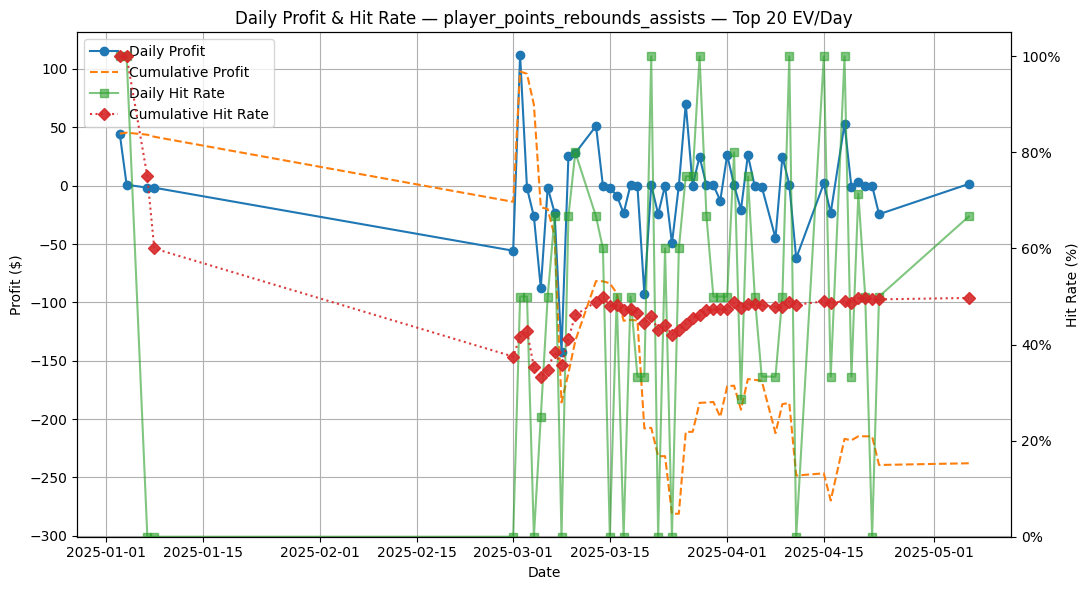

In [50]:
profit_df = plot_daily_profit(deduped_df, 'player_points_rebounds_assists', 20)

In [51]:
profit_df['profit'].sum()

np.float64(-237.81999999999994)

In [52]:
def rank_bet_type_performance(results: pd.DataFrame) -> pd.DataFrame:
    """
    Ranks each bet_type by hit_rate, cumulative_profit, and cumulative_hit_rate.

    Expects columns:
      - 'bet_type'
      - 'profit'  (numeric; >0 means the bet won)
      - (optional) anything else; not used here

    Returns a DataFrame with per-bet_type metrics and ranks.
    """
    required = {"bet_type", "profit"}
    missing = required - set(results.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = results.copy()

    # Win indicator
    df["won"] = (df["profit"] > 0).astype(int)

    # Aggregate per bet_type
    perf = (
        df.groupby("bet_type", as_index=False)
          .agg(
              bets=("won", "count"),
              hits=("won", "sum"),
              cumulative_profit=("profit", "sum"),
          )
    )

    # Metrics
    perf["hit_rate"] = perf["hits"] / perf["bets"]
    # cumulative_hit_rate across the whole period per bet_type == hit_rate
    perf["cumulative_hit_rate"] = perf["hit_rate"]

    # Ranks (higher is better → descending False)
    perf["hit_rate_rank"] = perf["hit_rate"].rank(ascending=False, method="min").astype(int)
    perf["cumulative_profit_rank"] = perf["cumulative_profit"].rank(ascending=False, method="min").astype(int)
    perf["cumulative_hit_rate_rank"] = perf["cumulative_hit_rate"].rank(ascending=False, method="min").astype(int)

    # Optional overall score/rank (sum of ranks; lower = better)
    perf["overall_rank_score"] = (
        perf["hit_rate_rank"] + perf["cumulative_profit_rank"] + perf["cumulative_hit_rate_rank"]
    )
    perf = perf.sort_values(["overall_rank_score", "cumulative_profit"], ascending=[True, False]).reset_index(drop=True)

    # Nice ordering of columns
    cols = [
        "bet_type", "bets", "hits",
        "hit_rate", "cumulative_profit", "cumulative_hit_rate",
        "hit_rate_rank", "cumulative_profit_rank", "cumulative_hit_rate_rank",
        "overall_rank_score",
    ]
    return perf[cols]

In [53]:
rank_bet_type_performance(deduped_df)

,bet_type,bets,hits,hit_rate,cumulative_profit,cumulative_hit_rate,hit_rate_rank,cumulative_profit_rank,cumulative_hit_rate_rank,overall_rank_score
0,player_points,524,238,0.454198,137.09,0.454198,2,2,2,6
1,player_points_rebounds_assists,173,86,0.497110,-237.82,0.497110,1,4,1,6
2,player_points_assists,130,57,0.438462,150.12,0.438462,3,1,3,7
3,player_assists,1975,865,0.437975,-4882.36,0.437975,4,5,4,13
4,player_points_rebounds,177,73,0.412429,-78.81,0.412429,6,3,6,15
5,player_threes,2222,920,0.414041,-11135.54,0.414041,5,6,5,16
6,player_rebounds,2349,954,0.406130,-15412.78,0.406130,7,7,7,21
